<Axes: xlabel='date'>

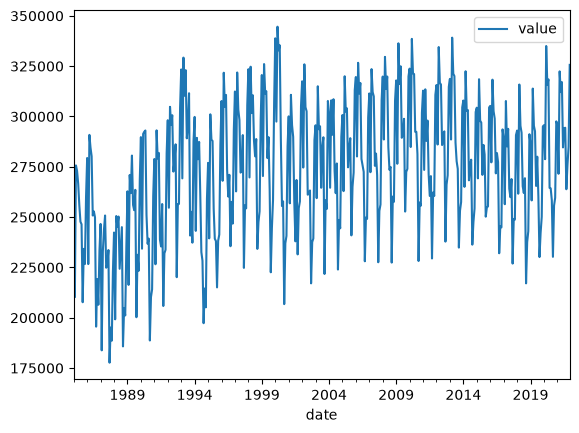

In [50]:
import pandas as pd
import os


df = pd.read_csv('data/Processing volume for dairy products.csv')\
    .dropna().drop(columns='total')
df_m=df.melt(id_vars='year',var_name='month')
df_m['date']=pd.to_datetime(df_m[['year','month']].assign(day=1))
df_m=df_m.drop(columns=['month','year'])\
    .set_index('date')

df_m=df_m.replace(',','',regex=True)\
        .astype(int)\
        .sort_index()
df_m.plot()


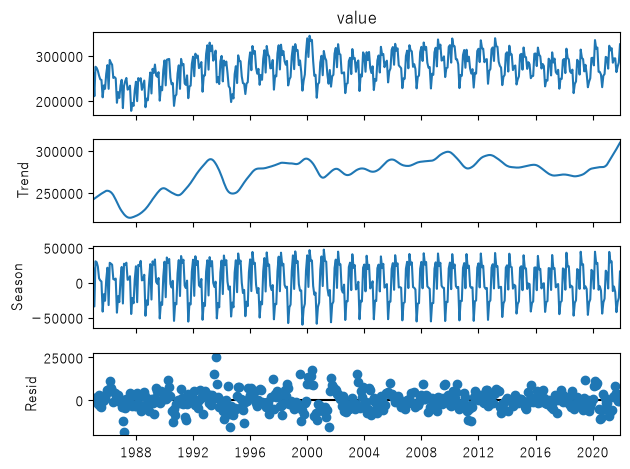

In [75]:
from statsmodels.tsa.seasonal import STL
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.family'] = 'YU Gothic'

stl=STL(df_m['value'],period=12)
result=stl.fit()
result.plot()
plt.show()

date
1987-03-01   -18421.522217
1993-08-01    25496.650326
2000-05-01    17540.010733
Name: resid, dtype: float64


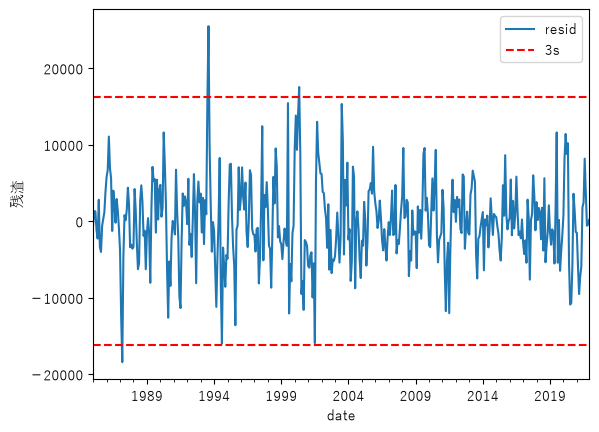

In [ ]:
import numpy as np

res=result.resid
std=res.std()
anomaly=res[res.abs()>3*std]

ax=res.plot()
ax.axhline(3*std,color='red',linestyle='--',label='3s')
ax.axhline(-3*std,color='red',linestyle='--')
ax.set_ylabel('残渣')
ax.legend()

print(anomaly)

